# фильтрация артефактов ЭМГ

## зависимости

Первая ячейка устанавливает `EMD-signal` именно в активное Python-окружение Jupyter. После первой установки перезапустите kernel и выполните notebook заново.

In [81]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("PyEMD") is None:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "EMD-signal"
    ])
    print("EMD-signal installed. Restart the kernel, then run all cells.")
else:
    print("EMD-signal is available in:", sys.executable)

EMD-signal is available in: /Library/Developer/CommandLineTools/usr/bin/python3


## импорты

In [82]:
from pathlib import Path

from IPython.display import display
from PyEMD import EMD
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from scipy import linalg, signal

mne.set_log_level("WARNING")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.grid"] = True


## пути

In [83]:
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

data_raw_dir = project_root / "data" / "raw"
data_interim_dir = project_root / "data" / "interim"
data_processed_dir = project_root / "data" / "processed"
figures_dir = project_root / "outputs" / "figures"
qc_dir = project_root / "outputs" / "qc"
tables_dir = project_root / "outputs" / "tables"

for folder in [data_interim_dir, data_processed_dir, figures_dir, qc_dir, tables_dir]:
    folder.mkdir(parents=True, exist_ok=True)

fif_path = data_raw_dir / "raw_artifacts_emg.fif"

# пути для ручного запуска
# fif_path = Path(r"/Users/user/Desktop/raw_artifacts_emg.fif")
# fif_path = Path(r"C:\\Users\\user\\Desktop\\raw_artifacts_emg.fif")

recording_name = (
    fif_path.name
    .removesuffix(".fif.gz")
    .removesuffix(".fif")
)
annotations_path = qc_dir / f"{recording_name}-annot.fif"
legacy_annotations_path = qc_dir / f"{recording_name}_annotations.csv"

print("Project root:", project_root)
print("Input FIF:", fif_path)
print("Annotations:", annotations_path)
print("Interim:", data_interim_dir)
print("Processed:", data_processed_dir)
print("Figures:", figures_dir)
print("QC:", qc_dir)
print("Tables:", tables_dir)


Project root: /Users/sofiaefimochkina/Documents/emg_artifacts_filter
Input FIF: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/data/raw/raw_artifacts_emg.fif
Annotations: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/outputs/qc/raw_artifacts_emg-annot.fif
Interim: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/data/interim
Processed: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/data/processed
Figures: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/outputs/figures
QC: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/outputs/qc
Tables: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/outputs/tables


## загрузка данных

In [84]:
if not fif_path.exists():
    raise FileNotFoundError(f"Файл не найден: {fif_path}")

raw_original = mne.io.read_raw_fif(fif_path, preload=True)
raw_original.set_channel_types({
    channel: "emg" for channel in raw_original.ch_names
})
raw_base = raw_original.copy()

# параметры влияют только на отображение, данные остаются в вольтах
emg_browser_kwargs = dict(
    duration=1.0,
    n_channels=8,
    scalings={"emg": 4e-3},
)

# восстанавливаем сохранённую разметку при повторном запуске
if annotations_path.exists():
    saved_annotations = mne.read_annotations(annotations_path)
    raw_base.set_annotations(saved_annotations)
    annotations_source = annotations_path
elif legacy_annotations_path.exists():
    # преобразуем onset старого CSV из времени Unix в секунды записи
    annotations_table = pd.read_csv(legacy_annotations_path)
    epoch = pd.Timestamp("1970-01-01", tz="UTC")
    annotation_onsets = (
        pd.to_datetime(annotations_table["onset"], utc=True) - epoch
    ).dt.total_seconds().to_numpy()
    saved_annotations = mne.Annotations(
        onset=annotation_onsets,
        duration=annotations_table["duration"].to_numpy(),
        description=annotations_table["description"].astype(str).to_numpy(),
        orig_time=None,
    )
    raw_base.set_annotations(saved_annotations)
    annotations_source = legacy_annotations_path
else:
    annotations_source = None

sfreq = raw_base.info["sfreq"]
duration_s = raw_base.n_times / sfreq

print("File:", fif_path.name)
print("Channels:", len(raw_base.ch_names))
print("sfreq:", sfreq)
print("Duration, s:", round(duration_s, 2))
print("First channels:", raw_base.ch_names[:10])
print("Annotations:", len(raw_base.annotations))
print("Annotations loaded from:", annotations_source or "input FIF")


File: raw_artifacts_emg.fif
Channels: 8
sfreq: 4000.0
Duration, s: 117.52
First channels: ['RF R', 'BF R', 'TA R', 'GM R', 'RF L', 'BF L', 'TA L', 'GM L']
Annotations: 4
Annotations loaded from: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/outputs/qc/raw_artifacts_emg-annot.fif


/var/folders/4f/nvx50d4x7h5362c46mct3m3c0000gn/T/ipykernel_26575/2653801219.py:4: RuntimeWarning: This filename (/Users/sofiaefimochkina/Documents/emg_artifacts_filter/data/raw/raw_artifacts_emg.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_original = mne.io.read_raw_fif(fif_path, preload=True)


## проверка записи

In [85]:
if "TA L" not in raw_base.info["bads"]:
    raw_base.info["bads"].append("TA L")

channels_table = pd.DataFrame(
    {
        "channel": raw_base.ch_names,
        "type": raw_base.get_channel_types(),
        "bad": [ch in raw_base.info["bads"] for ch in raw_base.ch_names],
    }
)

display(channels_table)
print(f"Sampling rate: {raw_base.info['sfreq']} Hz")
print(f"Duration: {duration_s:.2f} s")
print("Bad channels:", raw_base.info["bads"] or "none")

raw_base.plot(**emg_browser_kwargs)


,channel,type,bad
0,RF R,emg,False
1,BF R,emg,False
2,TA R,emg,False
3,GM R,emg,False
4,RF L,emg,False
5,BF L,emg,False
6,TA L,emg,True
7,GM L,emg,False


Sampling rate: 4000.0 Hz
Duration: 117.53 s
Bad channels: ['TA L']


## сохранение аннотаций (опционально, фильтрация их не использует)

In [86]:

raw_base.annotations.save(
    annotations_path,
    overwrite=True,
)

print(f"Сохранено аннотаций: {len(raw_base.annotations)}")
print("Файл:", annotations_path)

Сохранено аннотаций: 4
Файл: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/outputs/qc/raw_artifacts_emg-annot.fif


## выбор каналов

In [87]:
emg_channels = ["GM R", "GM L", "RF R", "RF L", "TA R", "TA L", "BF R", "BF L"]
right_channels = ["GM R", "RF R", "TA R", "BF R"]
left_channels = ["GM L", "RF L", "TA L", "BF L"]

excluded_channels = ["TA L"]

print("EMG channels:", emg_channels)
print("Right:", right_channels)
print("Left:", left_channels)
print("Excluded:", excluded_channels)


EMG channels: ['GM R', 'GM L', 'RF R', 'RF L', 'TA R', 'TA L', 'BF R', 'BF L']
Right: ['GM R', 'RF R', 'TA R', 'BF R']
Left: ['GM L', 'RF L', 'TA L', 'BF L']
Excluded: ['TA L']


## CAR глобальный

In [108]:
car_channels = [
    channel for channel in emg_channels
    if channel not in excluded_channels
]

raw_car_global = raw_base.copy()
reference_signal = raw_car_global.get_data(picks=car_channels).mean(axis=0)
channel_indices = [
    raw_car_global.ch_names.index(channel)
    for channel in car_channels
]
raw_car_global._data[channel_indices] -= reference_signal

car_global_path = data_interim_dir / "recording_car_global_raw.fif"
raw_car_global.save(car_global_path, overwrite=True)

print("Saved:", car_global_path)
raw_car_global.plot(**emg_browser_kwargs)

Saved: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/data/interim/recording_car_global_raw.fif


## CAR по сторонам

In [109]:
raw_car_left_right = raw_base.copy()

for side_channels in [right_channels, left_channels]:
    car_channels = [
        channel for channel in side_channels
        if channel not in excluded_channels
    ]
    reference_signal = raw_car_left_right.get_data(
        picks=car_channels
    ).mean(axis=0)
    channel_indices = [
        raw_car_left_right.ch_names.index(channel)
        for channel in car_channels
    ]
    raw_car_left_right._data[channel_indices] -= reference_signal

car_left_right_path = (
    data_interim_dir / "recording_car_left_right_raw.fif"
)
raw_car_left_right.save(car_left_right_path, overwrite=True)

print("Saved:", car_left_right_path)
raw_car_left_right.plot(**emg_browser_kwargs)

Saved: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/data/interim/recording_car_left_right_raw.fif


## подготовка методов

In [90]:
analysis_channels = [
    channel for channel in emg_channels
    if channel not in excluded_channels
]

missing_channels = [
    channel for channel in analysis_channels
    if channel not in raw_base.ch_names
]
if missing_channels:
    raise ValueError(f"В записи отсутствуют каналы: {missing_channels}")

print("Analysis channels:", analysis_channels)
print("Excluded channels:", excluded_channels)

Analysis channels: ['GM R', 'GM L', 'RF R', 'RF L', 'TA R', 'BF R', 'BF L']
Excluded channels: ['TA L']


### notch-фильтр 50 Гц

Все отсчёты от начала до конца записи используются для обучения, применения и метрик. Медленная часть (≤ 30 Гц) считается артефактом, нерегулярная быстрая часть — полезным ЭМГ. Регулярная сетевая компонента 50 Гц удаляется узким notch-фильтром.

In [110]:
LINE_FREQ_HZ = 50.0
LINE_NOTCH_Q = 30.0

emg_data = raw_base.get_data(picks=analysis_channels)
notch_b, notch_a = signal.iirnotch(
    LINE_FREQ_HZ,
    LINE_NOTCH_Q,
    fs=sfreq,
)
notched_emg_data = signal.filtfilt(notch_b, notch_a, emg_data, axis=1)

raw_notch = raw_base.copy().load_data()
notch_indices = [
    raw_notch.ch_names.index(channel)
    for channel in analysis_channels
]
raw_notch._data[notch_indices] = notched_emg_data

print("Notch frequency, Hz:", LINE_FREQ_HZ)
print("Notch Q:", LINE_NOTCH_Q)
raw_notch.plot(**emg_browser_kwargs)

Notch frequency, Hz: 50.0
Notch Q: 30.0


### непрерывные данные и частотное разделение

In [92]:
ARTIFACT_CUTOFF_HZ = 30.0  # медленнее: артефакт, быстрее: ЭМГ

lowpass_filter = signal.butter(
    4,
    ARTIFACT_CUTOFF_HZ,
    btype="lowpass",
    fs=sfreq,
    output="sos",
)
slow_artifact_data = signal.sosfiltfilt(
    lowpass_filter,
    emg_data,
    axis=1,
)
retained_emg_data = emg_data - slow_artifact_data

assert slow_artifact_data.shape == emg_data.shape
assert np.allclose(
    slow_artifact_data + retained_emg_data,
    emg_data,
)
print("Continuous training duration, s:", round(raw_base.n_times / sfreq, 3))
print("Slow-artifact cutoff, Hz:", ARTIFACT_CUTOFF_HZ)

Continuous training duration, s: 117.525
Slow-artifact cutoff, Hz: 30.0


## SVD rank-1 по медленной части всей записи

In [111]:
svd_covariance = np.cov(slow_artifact_data)
left_vectors, svd_singular_values, _ = np.linalg.svd(
    svd_covariance, full_matrices=False
)
artifact_direction = left_vectors[:, :1]  # главная компонента

# строим ортогональный проектор для удаления главной компоненты
svd_projector = (
    np.eye(len(analysis_channels))
    - artifact_direction @ artifact_direction.T
)

# удаляем rank-1 модель медленного артефакта на всей записи
svd_artifact_model = artifact_direction @ (artifact_direction.T @ slow_artifact_data)
svd_clean_data = emg_data - svd_artifact_model
raw_svd = raw_base.copy().load_data()
svd_indices = [
    raw_svd.ch_names.index(channel)
    for channel in analysis_channels
]
raw_svd._data[svd_indices] = svd_clean_data

svd_explained_fraction = (
    svd_singular_values[0] / svd_singular_values.sum()
)
print("First SVD covariance fraction:", round(svd_explained_fraction, 4))
print("Projector symmetric:", np.allclose(svd_projector, svd_projector.T))
print(
    "Projector idempotent:",
    np.allclose(svd_projector @ svd_projector, svd_projector),
)
print("SVD applied samples:", svd_clean_data.shape[1])
assert svd_clean_data.shape == emg_data.shape
assert np.isfinite(svd_clean_data).all()

raw_svd.plot(**emg_browser_kwargs)

First SVD covariance fraction: 0.431
Projector symmetric: True
Projector idempotent: True
SVD applied samples: 470100


## GED: медленный артефакт против быстрого ЭМГ по всей записи

### параметры

In [94]:
GED_REGULARIZATION = 0.05  # регуляризация ковариации
GED_MIN_POWER_RATIO = 3.0  # порог мощности

ged_model_path = qc_dir / "ged_slow_global_model.npz"
ged_output_path = data_interim_dir / "recording_ged_global_raw.fif"

print("Slow-artifact cutoff, Hz:", ARTIFACT_CUTOFF_HZ)

Slow-artifact cutoff, Hz: 30.0


### область обучения и применения

In [95]:
training_samples = raw_base.n_times
application_samples = raw_base.n_times
print("GED training samples:", training_samples)
print("GED application samples:", application_samples)

GED training samples: 470100
GED application samples: 470100


### модель артефакта

In [112]:
# межканальная ковариация
def covariance(data):
    centered_data = data - data.mean(axis=1, keepdims=True)
    sample_count = centered_data.shape[1]
    return centered_data @ centered_data.T / (sample_count - 1)


artifact_covariance = covariance(slow_artifact_data)
normal_covariance = covariance(retained_emg_data)
regularization = (
    GED_REGULARIZATION
    * np.trace(normal_covariance)
    / len(analysis_channels)
)
regularized_normal_covariance = (
    normal_covariance
    + regularization * np.eye(len(analysis_channels))
)

power_ratios, spatial_filters = linalg.eigh(
    artifact_covariance,
    regularized_normal_covariance,
)
selected_components = power_ratios > GED_MIN_POWER_RATIO
if not selected_components.any():
    raise ValueError("GED не нашёл компонент, специфичных для артефакта")

ged_filters = spatial_filters[:, selected_components]
component_signals = ged_filters.T @ slow_artifact_data

# возвращаем компоненты в пространство каналов для построения модели артефакта
spatial_patterns = (
    slow_artifact_data
    @ component_signals.T
    @ np.linalg.pinv(
        component_signals @ component_signals.T
    )
)
artifact_model = spatial_patterns @ component_signals

eigenvalue_table = pd.DataFrame({
    "slow artifact / retained EMG power": power_ratios[::-1],
    "remove": selected_components[::-1],
})
display(eigenvalue_table)
display(pd.DataFrame(
    spatial_patterns,
    index=analysis_channels,
    columns=[
        f"component {index + 1}"
        for index in range(selected_components.sum())
    ],
))

/var/folders/4f/nvx50d4x7h5362c46mct3m3c0000gn/T/ipykernel_26575/2280875232.py:36: RuntimeWarning: divide by zero encountered in matmul
  component_signals @ component_signals.T
/var/folders/4f/nvx50d4x7h5362c46mct3m3c0000gn/T/ipykernel_26575/2280875232.py:36: RuntimeWarning: overflow encountered in matmul
  component_signals @ component_signals.T
/var/folders/4f/nvx50d4x7h5362c46mct3m3c0000gn/T/ipykernel_26575/2280875232.py:36: RuntimeWarning: invalid value encountered in matmul
  component_signals @ component_signals.T


,slow artifact / retained EMG power,remove
0,4.461142,True
1,0.605329,False
2,0.447964,False
3,0.322486,False
4,0.128137,False
5,0.068712,False
6,0.035144,False


,component 1
GM R,-1.216734e-06
GM L,-2.478569e-06
RF R,3.436294e-07
RF L,-2.531622e-06
TA R,8.121180e-05
BF R,-2.566267e-07
BF L,-1.445809e-06


### вычитание компоненты

In [113]:
clean_emg_data = emg_data - artifact_model
raw_ged = raw_base.copy().load_data()
ged_indices = [
    raw_ged.ch_names.index(channel)
    for channel in analysis_channels
]
raw_ged._data[ged_indices] = clean_emg_data

print("GED applied samples:", clean_emg_data.shape[1])
assert clean_emg_data.shape == emg_data.shape
assert np.isfinite(clean_emg_data).all()

raw_ged.plot(**emg_browser_kwargs)

GED applied samples: 470100


## EMD: медленные IMF по всей записи

EMD применяется независимо к исходному `raw_base`. Для ускорения только модель медленного артефакта оценивается при 250 Гц; из исходного сигнала вычитается восстановленный артефакт, поэтому высокочастотный ЭМГ не заменяется ресемплированным сигналом.

In [98]:
EMD_TARGET_SFREQ = 250.0
EMD_ARTIFACT_CUTOFF_HZ = ARTIFACT_CUTOFF_HZ

emd_downsample = int(round(sfreq / EMD_TARGET_SFREQ))
if not np.isclose(sfreq / emd_downsample, EMD_TARGET_SFREQ):
    raise ValueError(
        f"sfreq={sfreq} Hz cannot be reduced exactly to "
        f"{EMD_TARGET_SFREQ} Hz with an integer factor"
    )
if EMD_TARGET_SFREQ <= 2 * EMD_ARTIFACT_CUTOFF_HZ:
    raise ValueError("EMD_TARGET_SFREQ must exceed twice the artifact cutoff")

def imf_median_frequency(imf, model_sfreq):
    frequencies, psd = signal.welch(
        imf,
        fs=model_sfreq,
        nperseg=min(imf.size, 4096),
    )
    cumulative_power = np.cumsum(psd)
    if cumulative_power[-1] <= np.finfo(float).eps:
        return 0.0
    median_index = np.searchsorted(
        cumulative_power, 0.5 * cumulative_power[-1]
    )
    return float(frequencies[median_index])

def emd_rms(data):
    return float(np.sqrt(np.mean(np.square(data))))

def decompose_emd_channel(channel_data):
    model_data = signal.resample_poly(
        channel_data, up=1, down=emd_downsample
    )
    decomposition = EMD()
    decomposition.emd(model_data)
    imfs, residue = decomposition.get_imfs_and_residue()
    median_frequencies = np.asarray([
        imf_median_frequency(imf, EMD_TARGET_SFREQ)
        for imf in imfs
    ])
    remove_imfs = median_frequencies <= EMD_ARTIFACT_CUTOFF_HZ
    artifact_model = residue.copy()
    if remove_imfs.any():
        artifact_model += imfs[remove_imfs].sum(axis=0)
    assert np.allclose(imfs.sum(axis=0) + residue, model_data)
    return model_data, imfs, residue, median_frequencies, remove_imfs, artifact_model

print("EMD model sampling rate, Hz:", EMD_TARGET_SFREQ)
print("EMD artifact cutoff, Hz:", EMD_ARTIFACT_CUTOFF_HZ)
print("Downsampling factor:", emd_downsample)

EMD model sampling rate, Hz: 250.0
EMD artifact cutoff, Hz: 30.0
Downsampling factor: 16


### синтетическая проверка EMD

In [99]:
synthetic_time = np.arange(int(round(4 * sfreq))) / sfreq
synthetic_slow = np.sin(2 * np.pi * 10 * synthetic_time)
synthetic_fast = 0.5 * np.sin(2 * np.pi * 80 * synthetic_time)
synthetic_signal = synthetic_slow + synthetic_fast
(
    _, synthetic_imfs, _, synthetic_frequencies,
    synthetic_remove, synthetic_artifact_lowrate,
) = decompose_emd_channel(synthetic_signal)
synthetic_artifact = signal.resample_poly(
    synthetic_artifact_lowrate, up=emd_downsample, down=1
)[:synthetic_signal.size]
synthetic_clean = synthetic_signal - synthetic_artifact

assert synthetic_remove.any()
assert (~synthetic_remove).any()
synthetic_check = pd.Series({
    "slow RMS after / before": emd_rms(synthetic_clean - synthetic_fast) / emd_rms(synthetic_slow),
    "fast RMS after / before": emd_rms(synthetic_clean) / emd_rms(synthetic_fast),
    "removed IMFs": int(synthetic_remove.sum()),
    "retained IMFs": int((~synthetic_remove).sum()),
})
display(synthetic_check.to_frame("value"))

,value
slow RMS after / before,0.105777
fast RMS after / before,1.020209
removed IMFs,3.000000
retained IMFs,1.000000


### EMD по каналам и построение `raw_emd`

In [114]:
emd_artifact_lowrate = []
emd_summary_rows = []

for channel_index, channel in enumerate(analysis_channels):
    (
        model_data, imfs, residue, median_frequencies,
        remove_imfs, artifact_lowrate,
    ) = decompose_emd_channel(emg_data[channel_index])
    emd_artifact_lowrate.append(artifact_lowrate)

    for imf_index, (imf, median_frequency, remove) in enumerate(
        zip(imfs, median_frequencies, remove_imfs), start=1
    ):
        emd_summary_rows.append({
            "channel": channel,
            "component": f"IMF {imf_index}",
            "median frequency, Hz": median_frequency,
            "RMS, V": emd_rms(imf),
            "remove": bool(remove),
        })
    emd_summary_rows.append({
        "channel": channel,
        "component": "residue",
        "median frequency, Hz": 0.0,
        "RMS, V": emd_rms(residue),
        "remove": True,
    })

emd_artifact_lowrate = np.asarray(emd_artifact_lowrate)
emd_artifact_model = signal.resample_poly(
    emd_artifact_lowrate, up=emd_downsample, down=1, axis=1
)
if emd_artifact_model.shape[1] < raw_base.n_times:
    missing = raw_base.n_times - emd_artifact_model.shape[1]
    emd_artifact_model = np.pad(
        emd_artifact_model, ((0, 0), (0, missing)), mode="edge"
    )
emd_artifact_model = emd_artifact_model[:, :raw_base.n_times]
emd_clean_data = emg_data - emd_artifact_model

raw_emd = raw_base.copy().load_data()
emd_indices = [raw_emd.ch_names.index(channel) for channel in analysis_channels]
raw_emd._data[emd_indices] = emd_clean_data
emd_summary = pd.DataFrame(emd_summary_rows)

assert emd_clean_data.shape == emg_data.shape
assert np.isfinite(emd_clean_data).all()
assert np.array_equal(
    raw_emd.get_data(picks=excluded_channels),
    raw_base.get_data(picks=excluded_channels),
)
assert emd_summary.groupby("channel")["remove"].any().all()
assert emd_summary[emd_summary["component"] != "residue"].groupby("channel")["remove"].apply(lambda values: (~values).any()).all()
display(emd_summary)
raw_emd.plot(**emg_browser_kwargs)

,channel,component,"median frequency, Hz","RMS, V",remove
0,GM R,IMF 1,49.987793,0.000093,False
1,GM R,residue,0.000000,0.000026,True
2,GM L,IMF 1,49.987793,0.000078,False
3,GM L,IMF 2,30.273438,0.000023,False
4,GM L,IMF 3,12.084961,0.000025,True
5,GM L,IMF 4,7.568359,0.000029,True
6,GM L,IMF 5,5.371094,0.000018,True
7,GM L,IMF 6,3.112793,0.000022,True
8,GM L,IMF 7,1.342773,0.000034,True
9,GM L,residue,0.000000,0.000036,True


## проверка сигнала

In [115]:
records = {
    "original": raw_base,
    "50 Hz notch": raw_notch,
    "global CAR": raw_car_global,
    "left/right CAR": raw_car_left_right,
    "SVD slow rank-1": raw_svd,
    "GED slow components": raw_ged,
    "EMD slow IMFs": raw_emd,
}

# среднеквадратичная амплитуда
def rms(data, axis=-1):
    return np.sqrt(np.mean(np.square(data), axis=axis))


rms_table = pd.DataFrame({
    name: rms(record.get_data(picks=analysis_channels), axis=1)
    for name, record in records.items()
}, index=analysis_channels)
rms_table.index.name = "channel"
display(rms_table)

clean_slow_artifact_data = signal.sosfiltfilt(
    lowpass_filter,
    clean_emg_data,
    axis=1,
)
clean_retained_emg_data = clean_emg_data - clean_slow_artifact_data

slow_artifact_rms = rms(slow_artifact_data, axis=1)
clean_slow_artifact_rms = rms(clean_slow_artifact_data, axis=1)
retained_emg_rms = rms(retained_emg_data, axis=1)
clean_retained_emg_rms = rms(clean_retained_emg_data, axis=1)

quality = pd.DataFrame({
    "slow artifact RMS after / before": (
        clean_slow_artifact_rms / slow_artifact_rms
    ),
    "retained EMG RMS after / before": (
        clean_retained_emg_rms / retained_emg_rms
    ),
    "slow artifact / EMG before": slow_artifact_rms / retained_emg_rms,
    "slow artifact / EMG after": (
        clean_slow_artifact_rms / clean_retained_emg_rms
    ),
}, index=analysis_channels)
quality.index.name = "channel"
display(quality)

,original,50 Hz notch,global CAR,left/right CAR,SVD slow rank-1,GED slow components,EMD slow IMFs
channel,,,,,,,
GM R,0.000097,0.000038,0.000067,0.000126,0.000096,0.000097,0.000094
GM L,0.000103,0.000075,0.000127,0.000124,0.000103,0.000103,0.000084
RF R,0.000238,0.000234,0.000232,0.000158,0.000222,0.000238,0.000222
RF L,0.000554,0.000549,0.000556,0.000450,0.000500,0.000554,0.000555
TA R,0.000216,0.000176,0.000169,0.000171,0.000203,0.000130,0.000128
BF R,0.000157,0.000154,0.000151,0.000090,0.000148,0.000157,0.000155
BF L,0.000289,0.000282,0.000277,0.000377,0.000266,0.000289,0.000284


,slow artifact RMS after / before,retained EMG RMS after / before,slow artifact / EMG before,slow artifact / EMG after
channel,,,,
GM R,0.995358,1.000027,0.275566,0.274279
GM L,0.996731,1.000013,0.829005,0.826285
RF R,0.999975,0.999995,0.257692,0.257687
RF L,0.999601,0.999978,0.307030,0.306914
TA R,0.172148,0.996929,1.396861,0.241207
BF R,0.999916,1.000006,0.367102,0.367069
BF L,0.999352,1.000016,0.356595,0.356358


## визуальное сравнение

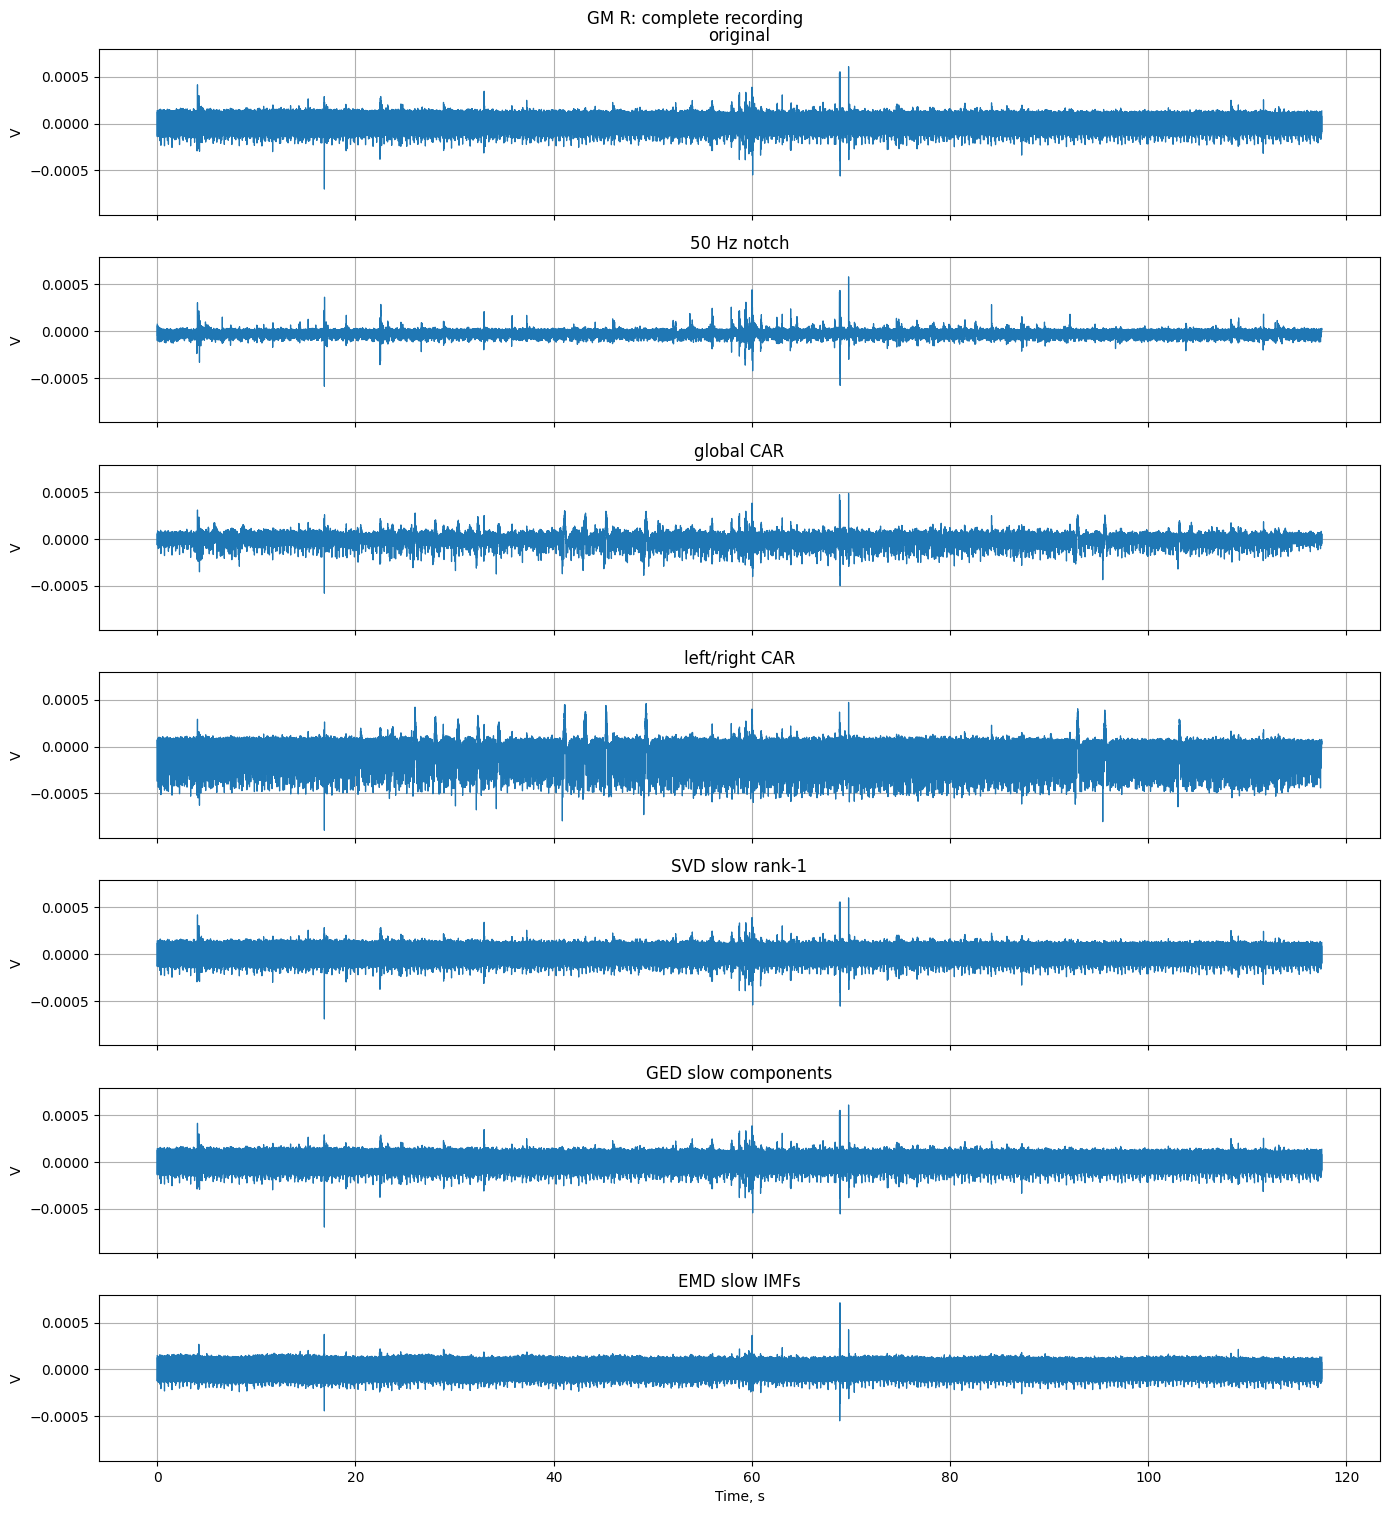

In [116]:
plot_channel = analysis_channels[0]
max_plot_points = 20_000
plot_step = max(1, raw_base.n_times // max_plot_points)
time = raw_base.times[::plot_step]

fig, axes = plt.subplots(
    len(records), 1, figsize=(14, 2.2 * len(records)), sharex=True, sharey=True
)
for axis, (name, record) in zip(axes, records.items()):
    values = record.get_data(picks=[plot_channel])[0, ::plot_step]
    axis.plot(time, values, linewidth=0.9)
    axis.set_title(name)
    axis.set_ylabel("V")
axes[-1].set_xlabel("Time, s")
fig.suptitle(f"{plot_channel}: complete recording")
fig.tight_layout()
plt.show()


## сохранение результатов

In [117]:
notch_output_path = data_interim_dir / "recording_notch_50hz_raw.fif"
notch_model_path = qc_dir / "notch_50hz_filter.npz"
emd_output_path = data_interim_dir / "recording_emd_global_raw.fif"
emd_model_path = qc_dir / "emd_slow_artifact_model.npz"
emd_summary_path = tables_dir / "emd_imf_summary.csv"
raw_notch.save(notch_output_path, overwrite=True)
raw_emd.save(emd_output_path, overwrite=True)
raw_ged.save(ged_output_path, overwrite=True)
svd_output_path = data_interim_dir / "recording_svd_k1_global_raw.fif"
svd_model_path = qc_dir / "svd_k1_slow_global_model.npz"
raw_svd.save(svd_output_path, overwrite=True)

np.savez(
    ged_model_path,
    channels=np.asarray(analysis_channels),
    covariance_artifact=artifact_covariance,
    covariance_normal=normal_covariance,
    eigenvalues=power_ratios,
    ged_filters=ged_filters,
    spatial_patterns=spatial_patterns,
    artifact_cutoff_hz=ARTIFACT_CUTOFF_HZ,
    training_samples=training_samples,
)

np.savez(
    svd_model_path,
    channels=np.asarray(analysis_channels),
    covariance=svd_covariance,
    singular_values=svd_singular_values,
    artifact_direction=artifact_direction,
    projector=svd_projector,
    artifact_cutoff_hz=ARTIFACT_CUTOFF_HZ,
    training_samples=training_samples,
)

np.savez(
    notch_model_path,
    channels=np.asarray(analysis_channels),
    line_freq_hz=LINE_FREQ_HZ,
    line_notch_q=LINE_NOTCH_Q,
    numerator=notch_b,
    denominator=notch_a,
)

np.savez_compressed(
    emd_model_path,
    channels=np.asarray(analysis_channels),
    artifact_model_lowrate=emd_artifact_lowrate,
    model_sfreq=EMD_TARGET_SFREQ,
    original_sfreq=sfreq,
    downsample_factor=emd_downsample,
    artifact_cutoff_hz=EMD_ARTIFACT_CUTOFF_HZ,
)
emd_summary.to_csv(emd_summary_path, index=False)

output_files = {
    "50 Hz notch": notch_output_path,
    "global CAR": car_global_path,
    "left/right CAR": car_left_right_path,
    "SVD slow rank-1": svd_output_path,
    "GED slow components": ged_output_path,
    "EMD slow IMFs": emd_output_path,
}
for name, path in output_files.items():
    print(f"{name}: {path}")
print("Notch model:", notch_model_path)
print("GED global model:", ged_model_path)
print("SVD global model:", svd_model_path)
print("EMD global model:", emd_model_path)
print("EMD IMF summary:", emd_summary_path)

50 Hz notch: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/data/interim/recording_notch_50hz_raw.fif
global CAR: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/data/interim/recording_car_global_raw.fif
left/right CAR: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/data/interim/recording_car_left_right_raw.fif
SVD slow rank-1: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/data/interim/recording_svd_k1_global_raw.fif
GED slow components: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/data/interim/recording_ged_global_raw.fif
EMD slow IMFs: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/data/interim/recording_emd_global_raw.fif
Notch model: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/outputs/qc/notch_50hz_filter.npz
GED global model: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/outputs/qc/ged_slow_global_model.npz
SVD global model: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/outputs/qc/svd_k1_slow_global_mod

## сравнение методов

### RMS

In [118]:
comparison_channels = analysis_channels
epsilon = np.finfo(float).eps

before_data = raw_base.get_data(picks=comparison_channels)
before_notched = signal.filtfilt(notch_b, notch_a, before_data, axis=1)
before_slow_artifact = signal.sosfiltfilt(
    lowpass_filter, before_notched, axis=1
)
before_retained_emg = before_notched - before_slow_artifact
whole_rms_before = rms(before_data, axis=1)
slow_artifact_rms_before = rms(before_slow_artifact, axis=1)
retained_emg_rms_before = rms(before_retained_emg, axis=1)

def line_band_power(data, center_hz=LINE_FREQ_HZ, half_width_hz=0.5):
    frequencies, psd = signal.welch(
        data,
        fs=sfreq,
        nperseg=min(data.shape[1], int(round(8 * sfreq))),
        axis=1,
    )
    line_bins = np.abs(frequencies - center_hz) <= half_width_hz
    frequency_step = frequencies[1] - frequencies[0]
    return psd[:, line_bins].sum(axis=1) * frequency_step

line_power_before = line_band_power(before_data)

metric_rows = []
channel_metrics = {}

for method, record in records.items():
    after_data = record.get_data(picks=comparison_channels)
    after_notched = signal.filtfilt(notch_b, notch_a, after_data, axis=1)
    after_slow_artifact = signal.sosfiltfilt(
        lowpass_filter, after_notched, axis=1
    )
    after_retained_emg = after_notched - after_slow_artifact
    whole_rms = rms(after_data, axis=1)
    slow_artifact_rms_after = rms(after_slow_artifact, axis=1)
    retained_emg_rms_after = rms(after_retained_emg, axis=1)
    line_power_after = line_band_power(after_data)
    values = {
        "Whole-recording RMS": whole_rms,
        "Whole-recording RMS ratio": whole_rms / (whole_rms_before + epsilon),
        "Slow artifact RMS ratio": (
            slow_artifact_rms_after / (slow_artifact_rms_before + epsilon)
        ),
        "Retained EMG RMS ratio": (
            retained_emg_rms_after / (retained_emg_rms_before + epsilon)
        ),
        "50 Hz power ratio": line_power_after / (line_power_before + epsilon),
        "Slow artifact / retained EMG": (
            slow_artifact_rms_after / (retained_emg_rms_after + epsilon)
        ),
    }
    channel_metrics[method] = pd.DataFrame(
        values,
        index=comparison_channels,
    )

    for metric, vector in values.items():
        q1, median, q3 = np.nanpercentile(vector, [25, 50, 75])
        metric_rows.append({
            "method": method,
            "metric": metric,
            "median": median,
            "q1": q1,
            "q3": q3,
        })

metrics_long = pd.DataFrame(metric_rows)

# форматируем медиану и межквартильный интервал
def format_metric(row):
    return f"{row['median']:.3f} [{row['q1']:.3f}–{row['q3']:.3f}]"


metrics_display = metrics_long.assign(
    value=metrics_long.apply(format_metric, axis=1)
).pivot(
    index="metric",
    columns="method",
    values="value",
)
metric_order = list(channel_metrics["original"].columns)
display(metrics_display.reindex(metric_order))

method,50 Hz notch,EMD slow IMFs,GED slow components,SVD slow rank-1,global CAR,left/right CAR,original
metric,,,,,,,
Whole-recording RMS,0.000 [0.000–0.000],0.000 [0.000–0.000],0.000 [0.000–0.000],0.000 [0.000–0.000],0.000 [0.000–0.000],0.000 [0.000–0.000],0.000 [0.000–0.000]
Whole-recording RMS ratio,0.976 [0.770–0.983],0.970 [0.875–0.983],1.000 [0.999–1.000],0.941 [0.928–0.968],0.960 [0.871–0.989],0.812 [0.728–1.253],1.000 [1.000–1.000]
Slow artifact RMS ratio,0.999 [0.999–1.000],0.903 [0.497–1.060],0.999 [0.996–1.000],0.870 [0.782–0.938],1.000 [0.983–1.104],1.034 [0.837–1.101],1.000 [1.000–1.000]
Retained EMG RMS ratio,0.996 [0.993–0.997],0.994 [0.970–0.995],1.000 [1.000–1.000],0.976 [0.970–0.983],0.974 [0.966–1.164],1.337 [0.718–3.038],1.000 [1.000–1.000]
50 Hz power ratio,0.001 [0.000–0.001],0.999 [0.998–1.000],1.000 [1.000–1.000],1.000 [0.996–1.011],0.355 [0.198–0.664],0.498 [0.347–1.084],1.000 [1.000–1.000]
Slow artifact / retained EMG,0.376 [0.339–1.475],0.367 [0.346–0.625],0.375 [0.338–1.203],0.344 [0.261–1.466],0.429 [0.342–1.235],0.539 [0.378–0.858],0.375 [0.339–1.451]


### сравнение до и после

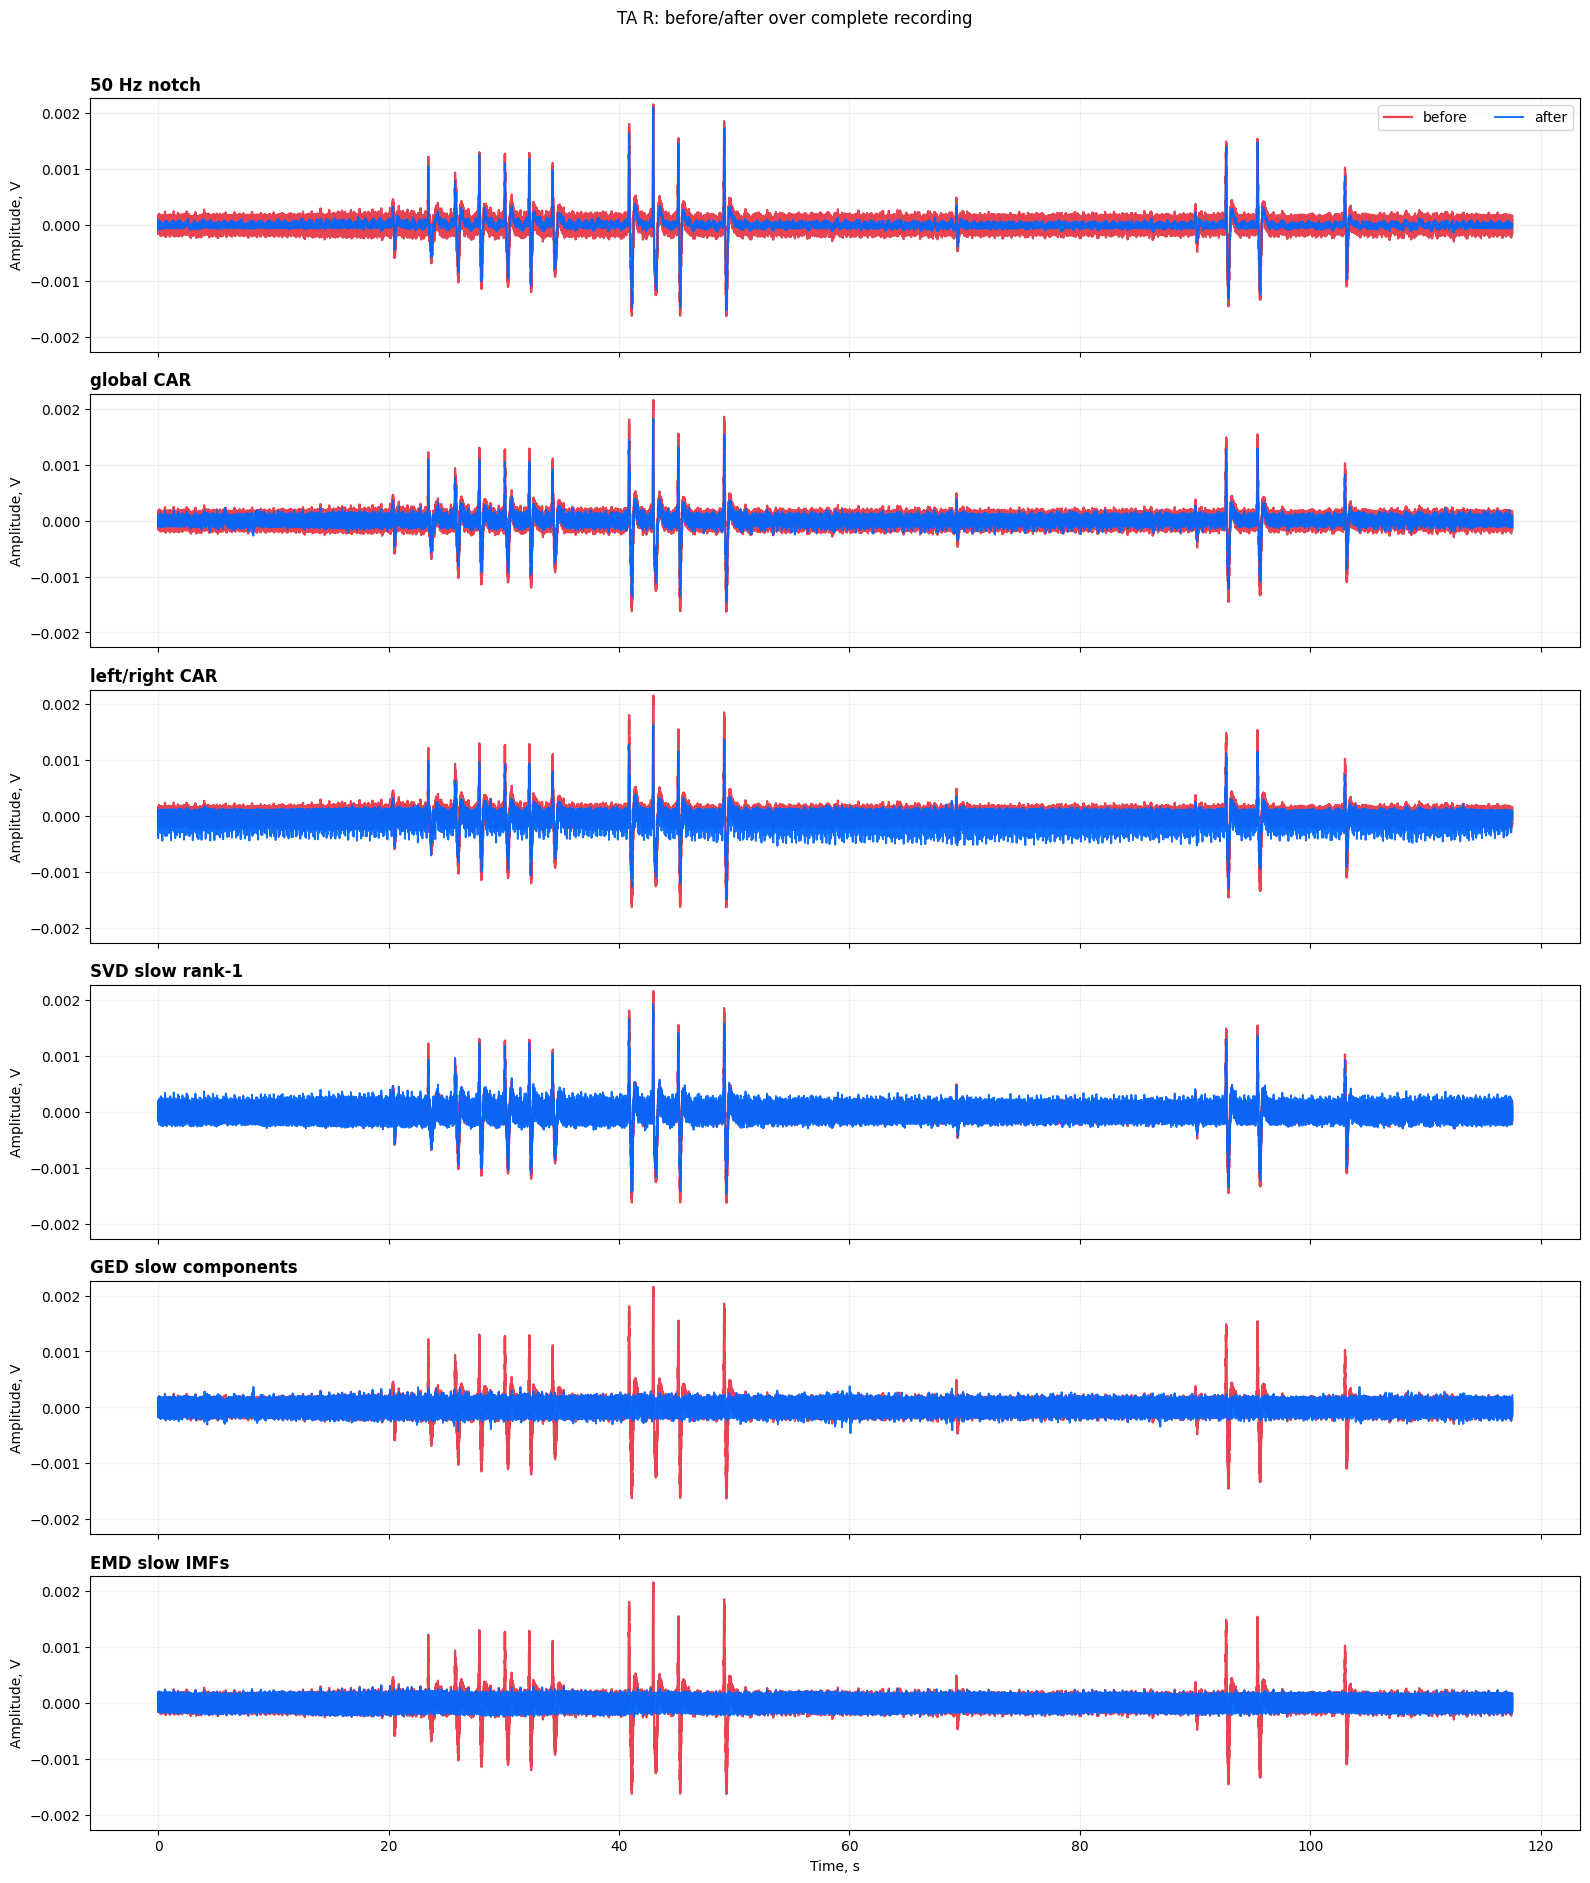

In [119]:
plot_channel = "TA R"  # канал для графика
method_records = {name: rec for name, rec in records.items() if name != "original"}
max_plot_points = 20_000
plot_step = max(1, raw_base.n_times // max_plot_points)
t = raw_base.times[::plot_step]
before_view = raw_base.get_data(picks=[plot_channel])[0, ::plot_step]
after_views = {
    name: rec.get_data(picks=[plot_channel])[0, ::plot_step]
    for name, rec in method_records.items()
}
all_signals = np.concatenate([before_view, *after_views.values()])
signal_limit = 1.05 * np.max(np.abs(all_signals))

fig, axes = plt.subplots(len(method_records), 1, figsize=(16, 3.1 * len(method_records)), sharex=True, sharey=True)
axes = np.atleast_1d(axes)
for ax, (method, after_view) in zip(axes, after_views.items()):
    ax.plot(t, before_view, color="#E63946", lw=1.6, alpha=0.95, label="before", zorder=3)
    ax.plot(t, after_view, color="#0066FF", lw=1.35, alpha=0.95, label="after", zorder=4)
    ax.set_ylim(-signal_limit, signal_limit)
    ax.set_ylabel("Amplitude, V")
    ax.set_title(method, loc="left", fontweight="bold")
    ax.grid(alpha=0.18)
axes[0].legend(loc="upper right", frameon=True, ncol=2)
axes[-1].set_xlabel("Time, s")
fig.suptitle(f"{plot_channel}: before/after over complete recording", y=1.01)
fig.tight_layout()
plt.show()


### отношения RMS

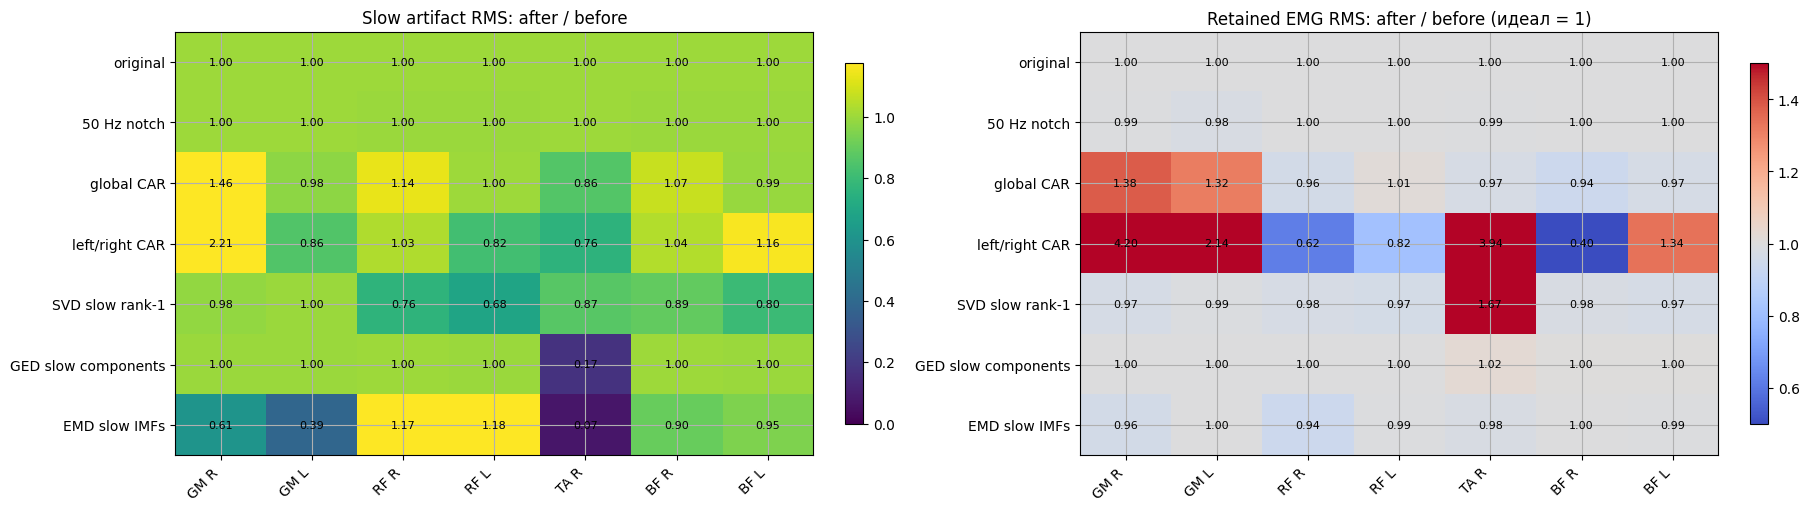

In [120]:
method_order = list(records)
artifact_heat = pd.DataFrame({m: channel_metrics[m]["Slow artifact RMS ratio"] for m in method_order}).T
normal_heat = pd.DataFrame({m: channel_metrics[m]["Retained EMG RMS ratio"] for m in method_order}).T

fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)
for ax, table, title, cmap, limits in [
    (axes[0], artifact_heat, "Slow artifact RMS: after / before", "viridis", (0, max(1, np.nanpercentile(artifact_heat, 95)))),
    (axes[1], normal_heat, "Retained EMG RMS: after / before (идеал = 1)", "coolwarm", (0.5, 1.5)),
]:
    image = ax.imshow(table, aspect="auto", cmap=cmap, vmin=limits[0], vmax=limits[1])
    ax.set_xticks(range(len(table.columns)), table.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(table.index)), table.index)
    ax.set_title(title)
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            ax.text(j, i, f"{table.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8, color="black")
    fig.colorbar(image, ax=ax, shrink=0.85)
plt.show()


### межканальные корреляции

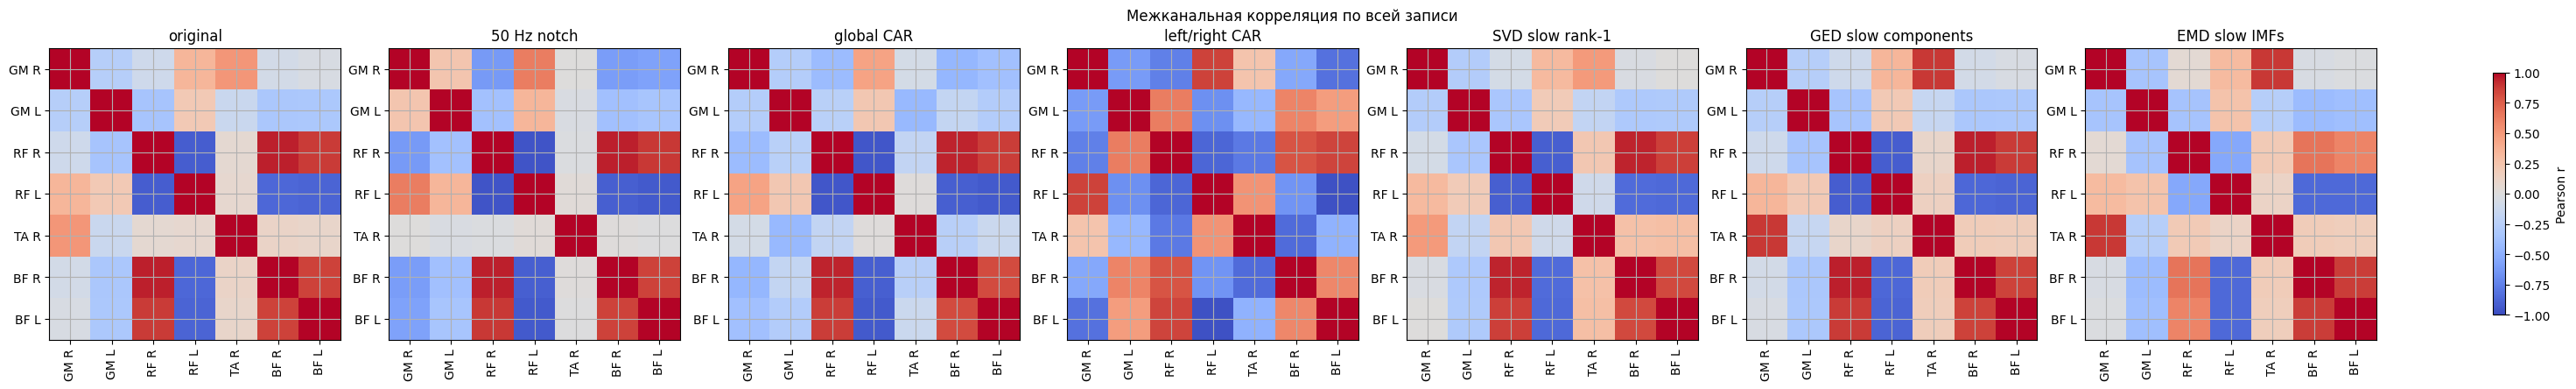

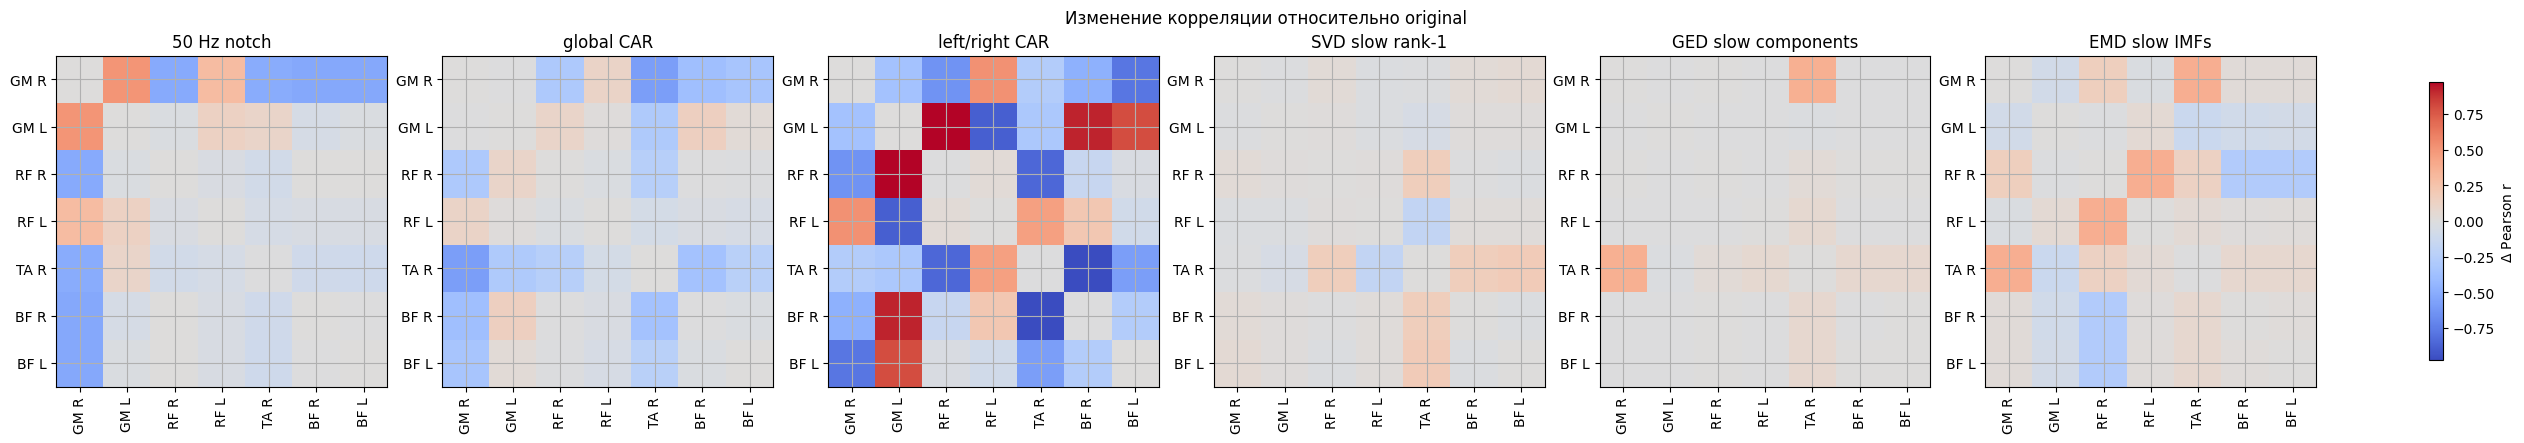

In [121]:
corr_matrices = {
    method: np.corrcoef(record.get_data(picks=comparison_channels))
    for method, record in records.items()
}
fig, axes = plt.subplots(1, len(corr_matrices), figsize=(4.2 * len(corr_matrices), 4.3), constrained_layout=True)
for ax, (method, matrix) in zip(axes, corr_matrices.items()):
    image = ax.imshow(matrix, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_title(method)
    ax.set_xticks(range(len(comparison_channels)), comparison_channels, rotation=90)
    ax.set_yticks(range(len(comparison_channels)), comparison_channels)
fig.colorbar(image, ax=axes, shrink=0.75, label="Pearson r")
fig.suptitle("Межканальная корреляция по всей записи")
plt.show()

# вычитаем исходную матрицу для оценки изменения корреляций
fig, axes = plt.subplots(1, len(corr_matrices) - 1, figsize=(4.2 * (len(corr_matrices) - 1), 4.3), constrained_layout=True)
delta_limit = max(np.max(np.abs(m - corr_matrices["original"])) for name, m in corr_matrices.items() if name != "original")
for ax, (method, matrix) in zip(axes, [(n, m) for n, m in corr_matrices.items() if n != "original"]):
    delta = matrix - corr_matrices["original"]
    image = ax.imshow(delta, cmap="coolwarm", vmin=-delta_limit, vmax=delta_limit)
    ax.set_title(method)
    ax.set_xticks(range(len(comparison_channels)), comparison_channels, rotation=90)
    ax.set_yticks(range(len(comparison_channels)), comparison_channels)
fig.colorbar(image, ax=axes, shrink=0.75, label=r"$\Delta$ Pearson r")
fig.suptitle("Изменение корреляции относительно original")
plt.show()
